# Practical session 2 - Practise with classic libraries

Students (pair):
- [Moulahi Amine](https://github.com/Moul4)
- [Saglier Valentin](https://github.com/valentin-sgl)

```
conda create --name=lab2 --file=requirement.txt
conda activate lab2
# do not forget to deactivate the environment if needed
# you can remove the environment once you are done
conda env remove --name=lab2
```

**Useful references for this lab**:

[1] `numpy`: [lecture notes (1.4.1-1.4.2)](https://scipy-lectures.org/intro/numpy/index.html) and [documentation](https://numpy.org/doc/stable/)

[2] `pandas`: [documentation](https://pandas.pydata.org/docs/getting_started/index.html), [quick tutorial](https://pandas.pydata.org/pandas-docs/version/0.15/10min.html)

[3] `matplotlib`: [lecture notes (1.5)](https://scipy-lectures.org/intro/matplotlib/index.html) and [documentation](https://matplotlib.org/)

[4] `h5py`: [quick start guide](http://docs.h5py.org/en/stable/quick.html#quick)

## <a name="content">Contents</a>
- [Exercise 1: Computing basic statistics](#ex1)
- [Exercise 2: Random variables and histograms](#ex2)
- [Exercise 3: Discrete isotropic total variation](#ex3)
---

In [22]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
## <a name="ex1">Exercise 1: Random variables and histograms</a>

In this exercise, we are interested in generating samples from the Gamma distribution $\mathcal{G}(\alpha,\beta)$, of probability density function (pdf)

\begin{equation}
    p(x) = \frac{\beta^\alpha}{\Gamma(\alpha)} x^{\alpha-1} \exp(-\beta x) \mathbb{1}_{\mathbb{R}_+^*}(x),
\end{equation}

and displaying their histogram. In the following, we consider $(\alpha, \beta) = (9, 2)$.

1\. Set the random seed to a fixed value for reproducibility, and biefly check your instruction works as intended.
> Hint: you may take a look at the following pages: [random module](https://numpy.org/doc/stable/reference/random/index.html?highlight=random#module-numpy.random), [random generator](https://numpy.org/doc/stable/reference/random/generator.html).

**Answer**:

In [23]:
import numpy as np

# 1. Fixer la graine aléatoire avec un générateur
seed = 42
rng = np.random.default_rng(seed)

# 2. Vérification simple
print("Premier tirage  :", rng.random(3))

# Réinitialisation avec la même graine pour vérifier la reproductibilité
rng_test = np.random.default_rng(seed)
print("Deuxième tirage :", rng_test.random(3))

Premier tirage  : [0.77395605 0.43887844 0.85859792]
Deuxième tirage : [0.77395605 0.43887844 0.85859792]


2\. Generate $\approx 10^5$ samples in a vector. Save the vector in a file, `samples.hdf5` or `samples.npy`.
> Warning / hint: 
> - take a careful look at the [documentation](https://numpy.org/doc/stable/reference/random/generated/numpy.random.gamma.html?highlight=gamma#numpy.random.gamma) (multiple conventions exist for the definition of the pdf underlying the distribution...);
> - to save data in a `npy` file, take a look at the example reported in the [Numpy documentation](https://numpy.org/doc/stable/reference/generated/numpy.save.html);
> - to save data in a `.h5` file, take a quick look at the [documentation here](https://docs.h5py.org/en/stable/quick.html#quick).

**Answer**:

In [24]:
import h5py

# Paramètres
alpha = 9
beta = 2
scale = 1 / beta  # theta = 1 / beta
n_samples = 100_000

# Fixation du générateur pour la reproductibilité
rng = np.random.default_rng(42)

# Génération des 10^5 échantillons
samples = rng.gamma(shape=alpha, scale=scale, size=n_samples)

# --- Option 1 : Sauvegarde en .npy (Méthode NumPy standard) ---
np.save("samples.npy", samples)

# --- Option 2 : Sauvegarde en .hdf5 (Méthode h5py) ---
with h5py.File("samples.hdf5", "w") as f:
    f.create_dataset("gamma_samples", data=samples)

print(
    f"Succès ! {len(samples)} échantillons générés et sauvegardés dans les fichiers."
)

Succès ! 100000 échantillons générés et sauvegardés dans les fichiers.


3\. Estimate an histogram of this distribution for a well chosen set of bins, and display it.
> Warnings: 
> - make sure the [histogram](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html?highlight=hist#matplotlib.pyplot.hist) corresponds to a probability density function (pdf);
> - do not forget to include a proper title with names for the axes.

**Answer**:

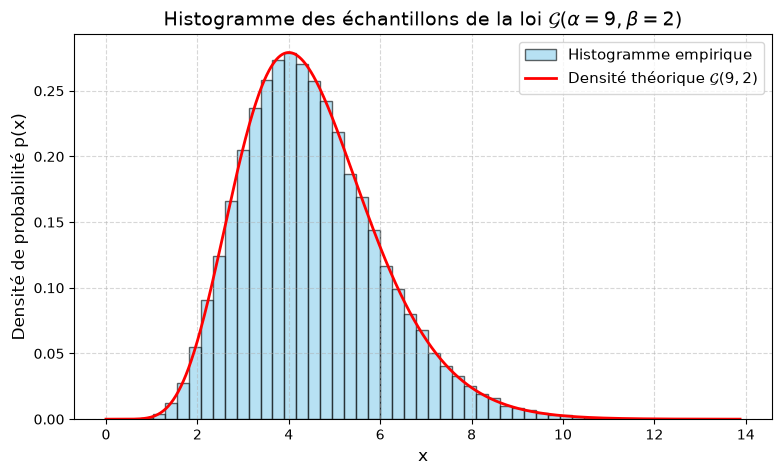

In [25]:
import matplotlib.pyplot as plt
from scipy.stats import gamma

# Traçage de l'histogramme
plt.figure(figsize=(9, 5))

# density=True permet de normaliser l'histogramme pour en faire une densité (aire = 1)
count, bins, ignored = plt.hist(
    samples,
    bins=50,
    density=True,
    alpha=0.6,
    color="skyblue",
    edgecolor="black",
    label="Histogramme empirique",
)

# Superposition de la densité théorique p(x)
x = np.linspace(0, max(samples), 1000)
pdf_theorique = gamma.pdf(x, a=alpha, scale=scale)
plt.plot(
    x,
    pdf_theorique,
    "r-",
    lw=2,
    label=f"Densité théorique $\mathcal{{G}}({alpha}, {beta})$",
)

# Titres et étiquettes des axes
plt.title(
    r"Histogramme des échantillons de la loi $\mathcal{G}(\alpha=9, \beta=2)$",
    fontsize=14,
)
plt.xlabel("x", fontsize=12)
plt.ylabel("Densité de probabilité p(x)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)

# Affichage
plt.show()

4\. Overlay the probability density function on the histogram and compare these in a few words. Save the resulting picture in `.png` format.
> Hint: 
> - take a look at the `scipy` [documentation](https://docs.scipy.org/doc/scipy/reference/stats.html) to avoid implementing the pdf from scratch;
> - return the bins in which the histogram is computed, and evaluate the pdf on those points.

**Answer**:

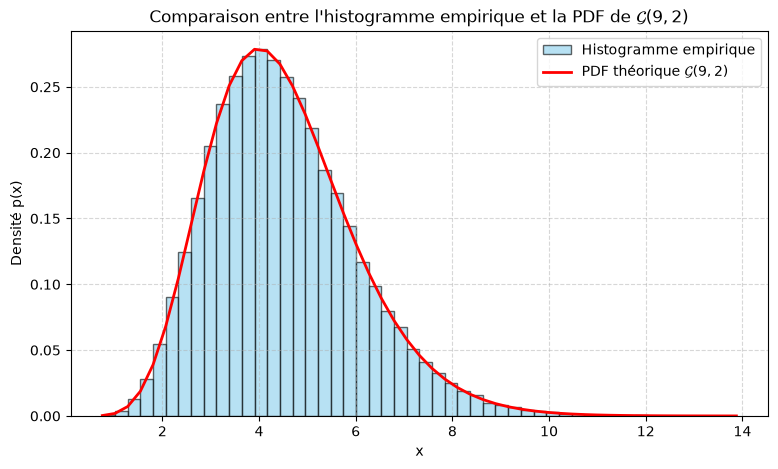

In [26]:
# Calcul de la PDF aux centres/bords des bins retournés par plt.hist
plt.figure(figsize=(9, 5))

counts, bins, patches = plt.hist(
    samples,
    bins=50,
    density=True,
    alpha=0.6,
    color="skyblue",
    edgecolor="black",
    label="Histogramme empirique",
)

# Évaluation de la PDF théorique aux points des bins
pdf_points = gamma.pdf(bins, a=alpha, scale=scale)

# Superposition de la courbe théorique
plt.plot(
    bins,
    pdf_points,
    "r-",
    linewidth=2,
    label=r"PDF théorique $\mathcal{G}(9, 2)$",
)

plt.title(
    r"Comparaison entre l'histogramme empirique et la PDF de $\mathcal{G}(9, 2)$"
)
plt.xlabel("x")
plt.ylabel("Densité p(x)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

# Sauvegarde de l'image
plt.savefig("gamma_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

Commentaire :
L'histogramme empirique coïncide presque parfaitement avec la courbe de densité théorique $p(x)$ sur tout le domaine. Cela s'explique par la taille importante de l'échantillon ($N = 10^5$), qui permet d'obtenir une convergence très précise de la distribution empirique vers la loi sous-jacente $\mathcal{G}(9, 2)$ (loi des grands nombres).

---
## <a name="ex2">Exercise 2: Basic statistics with `pandas`</a>

In this second exercise, we focus on computing basic statistics, and applying linear regression to a small data set. These data are gathered in the following table, which gives the infant mortality (`X`) and the gross national product per inhabitant (`Y`) of 12 european countries :

| `X` | 190 | 128 | 180 | 212 | 56 | 192 | 68 | 98 | 110 | 197 | 181 | 233 |
|-----|-----|-----|-----|----|-----|----|----|-----|-----|-----|-----|-----|
| `Y` |  24 |  28 |  24 | 19 |  37 | 22 | 34 |  25 |  36 |  24 |  20 |  18 |

1\. For `X `and `Y`, compute the median, mean, variance and standard deviation. The data points have already been entered into a `.csv` file stored in `data/data.csv`.
> Hint: 
> - you can directly use `pandas` to load the data into a `DataFrame` ([`pd.read_csv`](https://pandas.pydata.org/docs/reference/frame.html));
> - take a look at the built-in operations available for `DataFrame` objects ([documentation](https://pandas.pydata.org/docs/reference/frame.html));
> - to display a `DataFrame` `f`:
> ```python 
> from IPython.display import display
> display(df)
> ```
> - sort the `DataFrame` with respect to the value of `X` (see [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html#pandas.DataFrame.sort_values)) This will be useful for question 3.

**Answer**:

In [27]:
import pandas as pd
from IPython.display import display

# Chargement des données à partir du fichier CSV
df = pd.read_csv("data/data.csv")

# Tri du DataFrame selon la colonne X (comme suggéré dans les indices)
df = df.sort_values(by="X").reset_index(drop=True)

# Affichage du DataFrame
display(df)

# Calcul de la médiane, moyenne, variance et écart-type
stats = pd.DataFrame(
    {
        "Moyenne": df[["X", "Y"]].mean(),
        "Médiane": df[["X", "Y"]].median(),
        "Variance": df[["X", "Y"]].var(),
        "Écart-type": df[["X", "Y"]].std(),
    }
)

display(stats)

,X,Y
0,56,37
1,68,34
2,98,25
3,110,36
4,128,28
5,180,24
6,181,20
7,190,24
8,192,22
9,197,24


,Moyenne,Médiane,Variance,Écart-type
X,153.750000,180.5,3486.022727,59.042550
Y,25.916667,24.0,42.446970,6.515134


2\. Give the equation of the regression line of `Y` as a function of `X`.
> Hint: 
> - take a look at the functionalities available in `numpy` (e.g., `np.polyfit` and `np.polyval`);
> - if needed, note that you can retrieve the data from the resulting `pandas` `DataFrame` with the `to_numpy()` method.

**Answer**:

In [28]:
# Extraire les colonnes sous forme d'array NumPy
x = df["X"].to_numpy()
y = df["Y"].to_numpy()

# Ajuster un polynôme de degré 1 (régression linéaire Y = a*X + b)
# polyfit renvoie [a, b] où a est la pente (slope) et b l'ordonnée à l'origine (intercept)
a, b = np.polyfit(x, y, 1)

# Affichage des résultats et de l'équation
print(f"Pente (slope, a) : {a:.4f}")
print(f"Ordonnée à l'origine (intercept, b) : {b:.4f}")
print(f"\nÉquation de la droite de régression : Y = {a:.4f} * X + {b:.4f}")

Pente (slope, a) : -0.0982
Ordonnée à l'origine (intercept, b) : 41.0095

Équation de la droite de régression : Y = -0.0982 * X + 41.0095


3\. Display the cloud of points and the regression line $Y = f(X)$ on the same figure. Save the figure in `.png` format.

**Answer**:

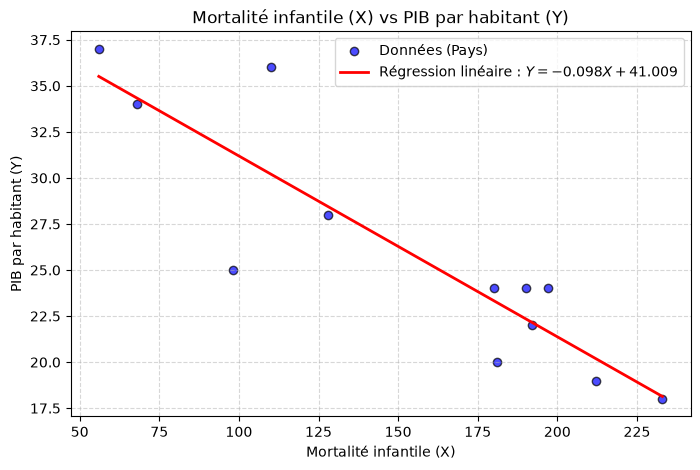

In [29]:
# Génération des points pour tracer la droite de régression
# On utilise la fonction affine Y = a*X + b (ou np.polyval)
x_line = np.linspace(df["X"].min(), df["X"].max(), 100)
y_line = np.polyval([a, b], x_line)

# Création de la figure
plt.figure(figsize=(8, 5))

# Nuage de points (data points)
plt.scatter(
    df["X"],
    df["Y"],
    color="blue",
    alpha=0.7,
    edgecolors="k",
    label="Données (Pays)",
)

# Droite de régression
plt.plot(
    x_line,
    y_line,
    color="red",
    linewidth=2,
    label=f"Régression linéaire : $Y = {a:.3f}X + {b:.3f}$",
)

# Personnalisation du graphique
plt.title("Mortalité infantile (X) vs PIB par habitant (Y)")
plt.xlabel("Mortalité infantile (X)")
plt.ylabel("PIB par habitant (Y)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

# 4. Sauvegarde au format .png
plt.savefig("regression_line.png", dpi=300, bbox_inches="tight")
plt.show()

---
## <a name="ex3">Exercise 3: Discrete isotropic total variation</a>

This exercise is devoted to the computation of the discrete isotropic total variation (TV) of an input matrix $\mathbf{X} = [\mathbf{x}_n]_{1 \leq n \leq N} \in\mathbb{C}^{M \times N}$, which is particularly useful in Bayesian inference (e.g., for inverse problems) to promote piece-wise smooth solutions. The TV is defined as

\begin{equation*}
    \text{TV}(\mathbf{X}) = \Vert D(\mathbf{X}) \Vert_{1,2} = \sum_{m=1}^M \sum_{n=1}^N \sqrt{[\mathbf{XD}_h]^2_{m,n} + [\mathbf{D}_v\mathbf{X}]^2_{m,n}},
\end{equation*}

where $[\mathbf{Z}]_{m,n}$ denotes the elements in position $(m,n)$ of the matrix $\mathbf{Z}$,

\begin{align*}
    D(X) &= (\mathbf{XD}_h, \mathbf{D}_v\mathbf{X}) \in \mathbb{C}^{M\times N} \times \mathbb{C}^{M\times N} \\
    %
    \mathbf{XD}_h &= [\mathbf{x}_2-\mathbf{x}_1, \dotsc, \mathbf{x}_N-\mathbf{x}_{N-1}, \mathbf{0}_M] \in \mathbb{C}^{M\times N} \\
    %
    \mathbf{D}_v\mathbf{X} &= [\tilde{\mathbf{x}}_2^T-\tilde{\mathbf{x}}^T_1, \dotsc, \tilde{\mathbf{x}}^T_M-\tilde{\mathbf{x}}^T_{M-1}, \mathbf{0}_N]^T \in \mathbb{C}^{M\times N},
\end{align*}

$\mathbf{x}_n \in \mathbb{C}^{M}$ is the $n$-th column of $\mathbf{X}$, and $\tilde{\mathbf{x}}_m \in \mathbb{C}^{1\times N}$ is the $m$-th row of $\mathbf{X}$. 
The linear operator $D: \mathbb{C}^{M\times N} \rightarrow \mathbb{C}^{M\times N} \times \mathbb{C}^{M\times N} $ is the discrete gradient operator. The adjoint of $D$, $D^*: \mathbb{C}^{M\times N} \times \mathbb{C}^{M\times N} \rightarrow \mathbb{C}^{M\times N}$, is given by

\begin{align*}
    (\forall \mathbf{Y} = (\mathbf{Y}_h,\mathbf{Y}_v)), \quad D^*(\mathbf{Y}) &= \mathbf{Y}_h\mathbf{D}^*_h + \mathbf{D}^*_v\mathbf{Y}_v \\
    %
    \mathbf{Y}_h\mathbf{D}^*_h &= \big[-\mathbf{y}_{h,1},- [\mathbf{y}_{h,n}-\mathbf{y}_{h,n-1}]_{2 \leq n \leq N-1}, \mathbf{y}_{h, N-1} \big] \\
    %
    \mathbf{D}^*_v\mathbf{Y}_v &= \big[-\tilde{\mathbf{y}}_{v,1}^T,- [\tilde{\mathbf{y}}_{v,m}^T-\tilde{\mathbf{y}}^T_{v,m-1}]_{2 \leq m \leq M-1}, \tilde{\mathbf{y}}^T_{v, M-1} \big]^T
\end{align*}

where $\mathbf{y}_{h,n}$ is the $n$-th column of $\mathbf{Y}_h$, and $\tilde{\mathbf{x}}_{v,m}$ is the $m$-th row of $\mathbf{Y}_v$.

1\. Using `numpy`, implement a function `gradient2D` to compute the 2D discrete gradient operator $D$ applied to a matrix $\mathbf{X}\in\mathbb{C}^{M \times N}$ (no for loops!). Trigger an error message whenever the input array has more than 2 dimensions. If not clear from the implementation, add a few short comments to explain your code.

> Hint: 
> - to trigger an error, you can for instance use an `assert` statement, or raise an [exception (e.g., `AssertionError`)](https://docs.python.org/3/library/exceptions.html);
> - only a few operations are needed: computing vertical differences, horizontal differences, and possibly a concatenation of matrices into a single tensor (= n-dimensional array);
> - possibly useful functions: `np.diff`, `np.c_`, `np.r_` (or `np.concatenate`). 

**Answer**:

In [30]:
import numpy as np

def gradient2D(X) :
    #On convertit l'entrée en tableau numpy si ce n'est pas déjà le cas
    X = np.asarray(X)

    #On vérifie que X ait bien deux dimensions maximum
    assert X.ndim <= 2, "X doit être un tableau 1D ou 2D"

    #Cas des tableaux à une dimension
    if X.ndim == 1:
        X = X[np.newaxis, :]  #On ajoute une dimension pour le traitement uniforme

    M, N = X.shape  #M = nombre de lignes, N = nombre de colonnes

    #Différences horizontales : X[: j+1] - X[: j]
    #np.c_ ajoute une colonne de zéros à la fin
    dx = np.c_[np.diff(X, axis=1), np.zeros((M, 1), dtype=X.dtype)] #dtype permet de conserver le type de valeur initial de X, et ainsi traiter les nombres complexes

    #Différences verticales : X[i+1 :] - X[i :]
    #np.r_ ajoute une ligne de zéros en bas
    dy = np.r_[np.diff(X, axis=0), np.zeros((1, N), dtype=X.dtype)] #dtype permet de conserver le type de valeur initial de X, et ainsi traiter les nombres complexes

    #Concaténation de dx et dy en un tableau 3D de dimension (2, M, N)
    return np.array([dx, dy])

2\. Implement a unit-test to validate the behaviour of the `gradient2D` function. For instance, you can check the format of the output, and test the result when the function is evaluated on a constant matrix (for both a square and a non-square input matrix). Run the unit-test from the present Jupyter notebook.

**Answer**:

In [31]:
from tests_exo3 import test_gradient2D
test_gradient2D(gradient2D)

Les tests ont été passés avec succès, la fonction gradient2D fonctionne correctement


3\. Document the function `gradient2D` with an appropriate docstring (see Lab 1).

**Answer**:

In [32]:
def gradient2D(X) :
    """
    Calcule l'opérateur de gradient discret 2D (D) appliqué à une matrice X.
    Cette fonction calcule les différences finies horizontales et verticales d'un tableau 2D, en préservant les dimensions spatiales d'origine grâce à l'ajout de zéros aux frontières.

    Paramètres :
        X : array_like
        X est une matrice 2D d'entrée de dimension (M, N), qui peut contenir des nombres réels ou complexes.

    Retours :
        grad : numpy.ndarray
        grad est un tableau 3D de dimension (2, M, N) représentant le gradient 2D de X.
        - grad[0, :, :] contient les différences horizontales (dx).
        - grad[1, :, :] contient les différences verticales (dy).

    Lève :
        AssertionError
        Si le tableau d'entrée X possède plus de 2 dimensions.
    """

    #On convertit l'entrée en tableau numpy si ce n'est pas déjà le cas
    X = np.asarray(X)

    #On vérifie que X ait bien deux dimensions maximum
    assert X.ndim <= 2, "X doit être un tableau 1D ou 2D"

    #Cas des tableaux à une dimension
    if X.ndim == 1:
        X = X[np.newaxis, :]  # On ajoute une dimension pour le traitement uniforme

    M, N = X.shape  # M = nombre de lignes, N = nombre de colonnes

    #Différences horizontales : X[: i+1] - X[: i]
    #np.c_ ajoute une colonne de zéros à la fin
    dx = np.c_[np.diff(X, axis=1), np.zeros((M, 1), dtype=X.dtype)] #dtype permet de conserver le type de valeur initial de X, et ainsi traiter les nombres complexes

    #Différences verticales : X[i+1 :] - X[i :]
    #np.r_ ajoute une ligne de zéros en bas
    dy = np.r_[np.diff(X, axis=0), np.zeros((1, N), dtype=X.dtype)] #dtype permet de conserver le type de valeur initial de X, et ainsi traiter les nombres complexes

    #Concaténation de dx et dy en un tableau 3D de dimension (2, M, N)
    return np.array([dx, dy])

4\. Using 1., define a function `tv` to compute $\text{TV}(\mathbf{X})$, $\mathbf{X}\in\mathbb{C}^{M \times N}$. Write a unit-test and document your function.

**Answer**:

In [33]:
def tv(X):
    """
    On calcule la variation totale (TV) isotrope d'une matrice X.

    La TV correspond à la somme des normes du gradient en chaque point de la matrice.
    Pour des valeurs complexes, la magnitude est calculée via le module des nombres complexes.

    Paramètres :
        X : array_like
        X est une matrice 2D d'entrée de dimension (M, N), qui peut contenir des nombres réels ou complexes.

    Retours :
        float
        La valeur scalaire de la TV.
    """
    #On calcul le gradient 2D avec la fonction gradient2D
    grad = gradient2D(X)

    #On calcul la norme du gradient en chaque élément (TV isotrope)
    # np.linalg.norm avec axis=0 calcule sqrt(|dx|^2 + |dy|^2) en chaque point
    normes_element = np.linalg.norm(grad, axis=0)

    # 3. La variation totale est la somme globale de ces normes
    return np.sum(normes_element)


In [34]:
from tests_exo3 import test_tv
test_tv(tv)

Tous les tests de la fonction tv() ont réussi avec succès !


5\. Implement a function `gradient2D_adjoint` to compute $D^*(\mathbf{Y})$, the adjoint of the 2D discrete gradient operator $D$ applied to $\mathbf{Y}\in\mathbb{C}^{M \times N}\times \mathbb{C}^{M \times N}$. Add a few short comments to explain your code whenever appropriate.

**Answer**:

In [35]:
def gradient2D_adjoint(Y):
    """
    Calcule l'opérateur adjoint D* du gradient discret 2D appliqué à un tenseur Y.

    Paramètres :
        Y : array_like
        Y est un tableau 3D de dimension (2, M, N) représentant les deux composantes du gradient (Y_x et Y_y), qui peut contenir des réels ou complexes.

    Retours :
        np.ndarray
        C'est une matrice 2D de dimension (M, N) correspondant au résultat de l'opérateur adjoint appliqué à Y.
    """
    Y = np.asarray(Y)

    #On vérifie le format de l'entrée : Y doit appartenir à C^{2 x M x N}
    assert Y.ndim == 3 and Y.shape[0] == 2, "Erreur : Y doit être de dimension (2, M, N)."

    #On sépare les composantes horizontale (Y_x) et verticale (Y_y)
    Y_x = Y[0]
    Y_y = Y[1]
    M, N = Y_x.shape

    #On détermine l'adjoint des différences horizontales (D_x*)
    dx_adj = np.zeros_like(Y_x)
    if N > 1:
        dx_adj[:, 0] = -Y_x[:, 0] #frontière gauche (j=0) : -Y_x[:, 0]
        dx_adj[:, 1:-1] = Y_x[:, :-2] - Y_x[:, 1:-1] #points intérieurs : Y_x[:, j-1] - Y_x[:, j]
        dx_adj[:, -1] = Y_x[:, -2] #frontière droite (j=N-1) : la dernière colonne valide de D_x correspondait à j=N-2

    #On détermine l'adjoint des différences verticales (D_y*)
    dy_adj = np.zeros_like(Y_y)
    if M > 1:
        dy_adj[0, :] = -Y_y[0, :] #frontière supérieure (i=0) : -Y_y[0, :]
        dy_adj[1:-1, :] = Y_y[:-2, :] - Y_y[1:-1, :] #points intérieurs : Y_y[i-1, :] - Y_y[i, :]
        dy_adj[-1, :] = Y_y[-2, :] #frontière inférieure (i=M-1) : la dernière ligne valide de D_y correspondait à i=M-2

    return dx_adj + dy_adj

6\. Implement a unit-test to validate `gradient2D_adjoint`, e.g., by checking the size of the output from the function and verifying that `gradient2D_adjoint` is adjoint to `gradient2D`, i.e., for any $\mathbf{X}\in\mathbb{C}^{M \times N}$ and $\mathbf{Y}\in\mathbb{C}^{M \times N}\times \mathbb{C}^{M \times N}$:

\begin{equation}
    \forall \mathbf{X} \in \mathbb{C}^{M \times N}, \mathbf{Y} = (\mathbf{Y}_h, \mathbf{Y}_v) \in \mathbb{C}^{M \times N} \times \mathbb{C}^{M \times N}, \;
    %
    \langle D(\mathbf{X}), \mathbf{Y} \rangle_{\mathbb{C}^{M \times N} \times \mathbb{C}^{M \times N}} = \langle \mathbf{X}, D^*(\mathbf{Y}) \rangle_{\mathbb{C}^{M \times N}}, 
\end{equation}

where 

\begin{align}
    &\forall \mathbf{U}, \mathbf{V} \in \mathbb{C}^{M \times N}, \; \langle \mathbf{U}, \mathbf{V} \rangle_{\mathbb{C}^{M \times N}} = \text{Tr}(\mathbf{U}^T \mathbf{V}) = \sum_{m=1}^M \sum_{n=1}^N u_{m,n}^* v_{m,n}, \\
    &\forall \mathbf{U} = (\mathbf{U}_h, \mathbf{U}_v), \mathbf{V} = (\mathbf{V}_h, \mathbf{V}_v) \in \mathbb{C}^{M \times N} \times \mathbb{C}^{M \times N}, \; \langle \mathbf{U}, \mathbf{V} \rangle_{\mathbb{C}^{M \times N} \times \mathbb{C}^{M \times N}} = \langle \mathbf{U}_h, \mathbf{V}_h \rangle_{\mathbb{C}^{M \times N}} + \langle \mathbf{U}_v, \mathbf{V}_v \rangle_{\mathbb{C}^{M \times N}}.
\end{align}

> Hint: to verify `gradient2D_adjoint` is the adjoint of `gradient2D`, evaluate the scalar products above for randomly drawn matrices. Set the random generator to a known state for reproducibility (see [Exercise 1](#ex1)).

> `np.conj` is useful.

**Answer**:

In [36]:
from tests_exo3 import test_gradient2D_adjoint
test_gradient2D_adjoint(gradient2D,gradient2D_adjoint)

Tous les tests pour gradient2D_adjoint ont réussi avec succès !


[Bonus, **optional**]. Generalize the `gradient2D` to any number of dimensions ($\mathbf{X} \in \mathbb{C}^{N_1 \times N_2 \times \dotsc \times N_p}$), i.e., by returning tensors obtained by computing differences along each of its dimensions.
> Hint: 
> - you may use a loops here, and/or list comprehension. Using slice objects (see [np.s_](https://numpy.org/doc/stable/reference/generated/numpy.s_.html?highlight=s_#numpy.s_) and [this page](https://stackoverflow.com/questions/24432209/python-index-an-array-using-the-colon-operator-in-an-arbitrary-dimension)) can be an interesting option.
>
> - the definition of the scalar product above can be extended to the case of tensors as follows:
\begin{equation}
    \mathbf{U}, \mathbf{V} \in \mathbb{C}^{N_1 \times N_2 \times \dotsc \times N_p}, \; \langle \mathbf{U}, \mathbf{V} \rangle_{\mathbb{C}^{N_1 \times N_2 \times \dotsc \times N_p}} =  \sum_{n_1 = 1}^{N_1}  \sum_{n_2 = 1}^{N_2} \dotsc \sum_{n_p = 1}^{N_p} u_{n_1, n_2, \dotsc, n_p}^* v_{n_1, n_2, \dotsc, n_p}   
\end{equation}

**Answer**:

In [37]:
def gradientND(X):
    """
    Généralise le gradient pour un tenseur X de dimension arbitraire p.

    Paramètres :
        X : array_like
        X est un tenseur de dimension p (N_1, N_2, ..., N_p)

    Retours :
        np.ndarray
        Tenseur de dimension p+1 (p, N_1, N_2, ..., N_p).
        Le premier axe correspond au gradient le long de chacune des p dimensions.
    """
    X = np.asarray(X)
    p = X.ndim

    #On crée une liste qui va stocker le gradient pour chaque dimension
    grads = []

    for k in range(p):
        #On calcule des différences le long de l'axe k
        diff_k = np.diff(X, axis=k)

        #On crée un tenseur de zéros de la forme exacte de X
        grad_k = np.zeros_like(X)

        #On construit de manière dynamique des index de "slicing"
        slices = [slice(None)] * p

        # Pour l'axe k en cours, on remplace par ":-1" (tout sauf le dernier élément)
        slices[k] = slice(None, -1)

        # On ajoute les différences dans notre tenseur rempli de zéros.
        grad_k[tuple(slices)] = diff_k

        grads.append(grad_k)

    #On empile tous les gradients calculés sur un nouvel axe (axe 0)
    return np.stack(grads, axis=0)

## Reference

```bibtex
@article{condat:hal-01309685,
  TITLE = {{Discrete Total Variation: New Definition and Minimization}},
  AUTHOR = {Condat, Laurent},
  URL = {https://hal.archives-ouvertes.fr/hal-01309685},
  JOURNAL = {{SIAM Journal on Imaging Sciences}},
  PUBLISHER = {{Society for Industrial and Applied Mathematics}},
  VOLUME = {10},
  NUMBER = {3},
  PAGES = {1258--1290},
  YEAR = {2017},
  MONTH = Aug,
  DOI = {10.1137/16M1075247},
  KEYWORDS = { variational image processing ; total variation ;  finite-difference schemes ;  coarea formula},
  PDF = {https://hal.archives-ouvertes.fr/hal-01309685v3/file/Condat-newTV.pdf},
  HAL_ID = {hal-01309685},
  HAL_VERSION = {v3},
}
```
